In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import plotly.express as px

In [14]:
import geodatasets

In [15]:
geodatasets.data.flatten().keys()

dict_keys(['geoda.airbnb', 'geoda.atlanta', 'geoda.cars', 'geoda.charleston1', 'geoda.charleston2', 'geoda.chicago_health', 'geoda.chicago_commpop', 'geoda.chile_labor', 'geoda.cincinnati', 'geoda.cleveland', 'geoda.grid100', 'geoda.groceries', 'geoda.guerry', 'geoda.health', 'geoda.health_indicators', 'geoda.hickory1', 'geoda.hickory2', 'geoda.home_sales', 'geoda.houston', 'geoda.juvenile', 'geoda.lansing1', 'geoda.lansing2', 'geoda.lasrosas', 'geoda.liquor_stores', 'geoda.malaria', 'geoda.milwaukee1', 'geoda.milwaukee2', 'geoda.ncovr', 'geoda.natregimes', 'geoda.ndvi', 'geoda.nepal', 'geoda.nyc', 'geoda.nyc_earnings', 'geoda.nyc_education', 'geoda.nyc_neighborhoods', 'geoda.orlando1', 'geoda.orlando2', 'geoda.oz9799', 'geoda.phoenix_acs', 'geoda.police', 'geoda.sacramento1', 'geoda.sacramento2', 'geoda.savannah1', 'geoda.savannah2', 'geoda.seattle1', 'geoda.seattle2', 'geoda.sids', 'geoda.sids2', 'geoda.south', 'geoda.spirals', 'geoda.stlouis', 'geoda.tampa1', 'geoda.us_sdoh', 'ny.bb

In [16]:
url = "https://github.com/Nowosad/spData/raw/refs/heads/master/inst/shapes/cycle_hire_osm.geojson"
gdf = gpd.read_file(url)

In [19]:
# Extract latitude and longitude from the geometry column
gdf['lat'] = gdf.geometry.y
gdf['lon'] = gdf.geometry.x

In [10]:
geodatasets.data.query_name('spdata.cycle_hire_osm')

{'url': 'https://github.com/Nowosad/spData/raw/refs/heads/master/inst/shapes/cycle_hire_osm.geojson',
 'license': 'CC0',
 'attribution': 'spData',
 'name': 'spdata.cycle_hire_osm',
 'description': 'Cycle hire points in London from OSM',
 'geometry_type': 'Point',
 'details': 'https://jakubnowosad.com/spData/reference/cycle_hire_osm.html',
 'nrows': 532,
 'ncols': 6,
 'hash': '804e7298bc5e84d6a73f212bdd19b7f3926ee0f50a3dbd957c46c07950dcc267',
 'filename': 'cycle_hire_osm.geojson'}

In [21]:
for col in gdf.columns:
    print(col)

osm_id
name
capacity
cyclestreets_id
description
geometry
lat
lon


In [27]:
gdf.capacity

0       24
1      NaN
2       21
3      NaN
4      NaN
      ... 
527    NaN
528    NaN
529    NaN
530    NaN
531    NaN
Name: capacity, Length: 532, dtype: str

In [28]:
fig = px.scatter_map(
    gdf,
    lat='lat',
    lon='lon',
    #size='capacity',  # Fixed size for all points
    #projection='mercator',
    center=dict(lat=51.5074, lon=-0.1278),  # Center on London
    zoom=10,
    #mapbox_style='open-street-map',
    title='Bicycle Hire Points in London (Scatter Plot)',
    height=600,
    width=800
)
fig.show()

In [11]:
import geopandas as gpd
import plotly.express as px

# Load the GeoJSON data from the URL
#new_gdf = gpd.read_file(geodatasets.get_url('spdata.cycle_hire_osm'))
url = "https://github.com/Nowosad/spData/raw/refs/heads/master/inst/shapes/cycle_hire_osm.geojson"
gdf = gpd.read_file(url)

# Extract latitude and longitude from the geometry column
gdf['lat'] = gdf.geometry.y
gdf['lon'] = gdf.geometry.x

# Create a density heatmap using Plotly Express
fig = px.density_mapbox(
    gdf,
    lat='lat',
    lon='lon',
    z=None,  # Use default density calculation
    radius=15,
    center=dict(lat=51.5074, lon=-0.1278),  # Center on London
    zoom=10,
    mapbox_style='open-street-map',
    title='Bicycle Hire Points Density in London (OSM)',
    height=600,
    width=800
)

# Show the figure
fig.show()

/tmp/ipykernel_794046/2722380361.py:14: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(


<Axes: >

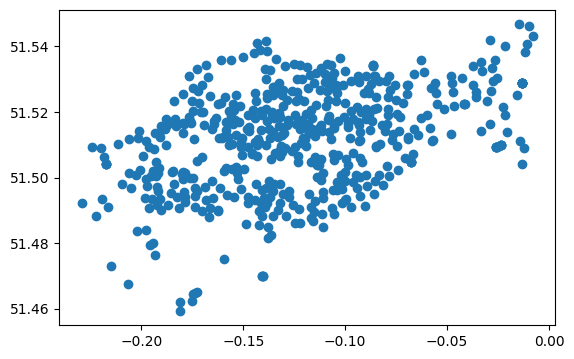

In [8]:
new_gdf.plot()

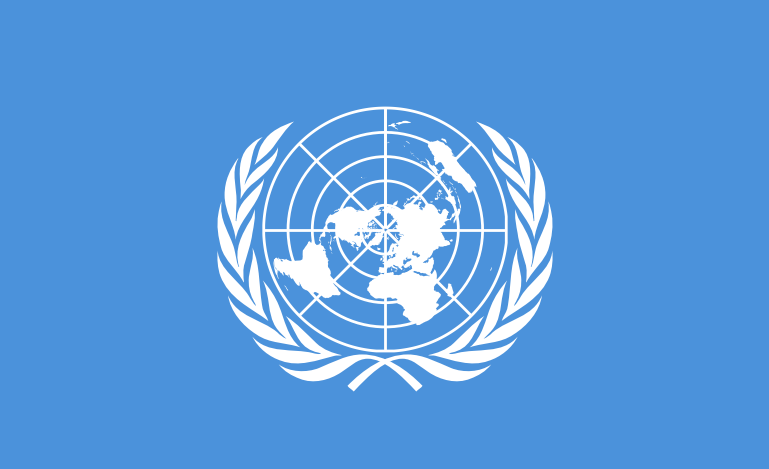

In [25]:
from matplotlib.patches import PathPatch
import matplotlib.path
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib.transforms import Bbox, BboxTransform
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# When drawing the flag, we can either use white filled land, or be a little
# more fancy and use the Natural Earth shaded relief imagery.
filled_land = True


def olive_path():
    """
    Return a Matplotlib path representing a single olive branch from the
    UN Flag. The path coordinates were extracted from the SVG at
    https://commons.wikimedia.org/wiki/File:Flag_of_the_United_Nations.svg.

    """
    olives_verts = np.array(
        [[0,   2,   6,   9,  30,  55,  79,  94, 104, 117, 134, 157, 177,
          188, 199, 207, 191, 167, 149, 129, 109,  87,  53,  22,   0, 663,
          245, 223, 187, 158, 154, 150, 146, 149, 154, 158, 181, 184, 197,
          181, 167, 153, 142, 129, 116, 119, 123, 127, 151, 178, 203, 220,
          237, 245, 663, 280, 267, 232, 209, 205, 201, 196, 196, 201, 207,
          211, 224, 219, 230, 220, 212, 207, 198, 195, 176, 197, 220, 239,
          259, 277, 280, 663, 295, 293, 264, 250, 247, 244, 240, 240, 243,
          244, 249, 251, 250, 248, 242, 245, 233, 236, 230, 228, 224, 222,
          234, 249, 262, 275, 285, 291, 295, 296, 295, 663, 294, 293, 292,
          289, 294, 277, 271, 269, 268, 265, 264, 264, 264, 272, 260, 248,
          245, 243, 242, 240, 243, 245, 247, 252, 256, 259, 258, 257, 258,
          267, 285, 290, 294, 297, 294, 663, 285, 285, 277, 266, 265, 265,
          265, 277, 266, 268, 269, 269, 269, 268, 268, 267, 267, 264, 248,
          235, 232, 229, 228, 229, 232, 236, 246, 266, 269, 271, 285, 285,
          663, 252, 245, 238, 230, 246, 245, 250, 252, 255, 256, 256, 253,
          249, 242, 231, 214, 208, 208, 227, 244, 252, 258, 262, 262, 261,
          262, 264, 265, 252, 663, 185, 197, 206, 215, 223, 233, 242, 237,
          237, 230, 220, 202, 185, 663],
         [8,   5,   3,   0,  22,  46,  46,  46,  35,  27,  16,  10,  18,
          22,  28,  38,  27,  26,  33,  41,  52,  52,  52,  30,   8, 595,
          77,  52,  61,  54,  53,  52,  53,  55,  55,  57,  65,  90, 106,
          96,  81,  68,  58,  54,  51,  50,  51,  50,  44,  34,  43,  48,
          61,  77, 595, 135, 104, 102,  83,  79,  76,  74,  74,  79,  84,
          90, 109, 135, 156, 145, 133, 121, 100,  77,  62,  69,  67,  80,
          92, 113, 135, 595, 198, 171, 156, 134, 129, 124, 120, 123, 126,
          129, 138, 149, 161, 175, 188, 202, 177, 144, 116, 110, 105,  99,
          108, 116, 126, 136, 147, 162, 173, 186, 198, 595, 249, 255, 261,
          267, 241, 222, 200, 192, 183, 175, 175, 175, 175, 199, 221, 240,
          245, 250, 256, 245, 233, 222, 207, 194, 180, 172, 162, 153, 154,
          171, 184, 202, 216, 233, 249, 595, 276, 296, 312, 327, 327, 327,
          327, 308, 284, 262, 240, 240, 239, 239, 242, 244, 247, 265, 277,
          290, 293, 296, 300, 291, 282, 274, 253, 236, 213, 235, 252, 276,
          595, 342, 349, 355, 357, 346, 326, 309, 303, 297, 291, 290, 297,
          304, 310, 321, 327, 343, 321, 305, 292, 286, 278, 270, 276, 281,
          287, 306, 328, 342, 595, 379, 369, 355, 343, 333, 326, 318, 328,
          340, 349, 366, 373, 379, 595]]).T
    olives_codes = np.array([1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 4, 4, 4, 4, 4, 79, 1, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 4, 4, 79, 1, 4, 4, 4, 4, 4, 4, 2, 4,
                             4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 79, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 79, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 4,
                             4, 4, 4, 4, 4, 79, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 4, 4, 79, 1, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 4, 4, 79, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                             4, 4, 79], dtype=np.uint8)

    return matplotlib.path.Path(olives_verts, olives_codes)



blue = '#4b92db'

# We're drawing a flag with a 3:5 aspect ratio.
fig = plt.figure(figsize=[7.5, 4.5], facecolor=blue)
# Put a blue background on the figure.
blue_background = PathPatch(matplotlib.path.Path.unit_rectangle(),
                            transform=fig.transFigure, color=blue,
                            zorder=-1)
fig.patches.append(blue_background)

# Set up the Azimuthal Equidistant and Plate Carree projections
# for later use.
az_eq = ccrs.AzimuthalEquidistant(central_latitude=90)
pc = ccrs.PlateCarree()

# Pick a suitable location for the map (which is in an Azimuthal
# Equidistant projection).
ax = fig.add_axes([0.25, 0.24, 0.5, 0.54], projection=az_eq)

# The background patch is not needed in this example.
ax.patch.set_facecolor('none')
# The Axes frame produces the outer meridian line.
for spine in ax.spines.values():
    spine.update({'edgecolor': 'white', 'linewidth': 2})

# We want the map to go down to -60 degrees latitude.
ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

# Importantly, we want the axes to be circular at the -60 latitude
# rather than cartopy's default behaviour of zooming in and becoming
# square.
_, patch_radius = az_eq.transform_point(0, -60, pc)
circular_path = matplotlib.path.Path.circle(0, patch_radius)
ax.set_boundary(circular_path)

if filled_land:
    ax.add_feature(
        cfeature.LAND, facecolor='white', edgecolor='none')
else:
    ax.stock_img()

gl = ax.gridlines(crs=pc, linewidth=2, color='white', linestyle='-')
# Meridians every 45 degrees, and 4 parallels.
gl.xlocator = matplotlib.ticker.FixedLocator(np.arange(-180, 181, 45))
parallels = np.arange(-30, 70, 30)
gl.ylocator = matplotlib.ticker.FixedLocator(parallels)

# Now add the olive branches around the axes. We do this in normalised
# figure coordinates
olive_leaf = olive_path()

olives_bbox = Bbox.null()
olives_bbox.update_from_path(olive_leaf)

# The first olive branch goes from left to right.
olive1_axes_bbox = Bbox([[0.45, 0.15], [0.725, 0.75]])
olive1_trans = BboxTransform(olives_bbox, olive1_axes_bbox)

# THe second olive branch goes from right to left (mirroring the first).
olive2_axes_bbox = Bbox([[0.55, 0.15], [0.275, 0.75]])
olive2_trans = BboxTransform(olives_bbox, olive2_axes_bbox)

olive1 = PathPatch(olive_leaf, facecolor='white', edgecolor='none',
                    transform=olive1_trans + fig.transFigure)
olive2 = PathPatch(olive_leaf, facecolor='white', edgecolor='none',
                    transform=olive2_trans + fig.transFigure)

fig.patches.append(olive1)
fig.patches.append(olive2)

plt.show()




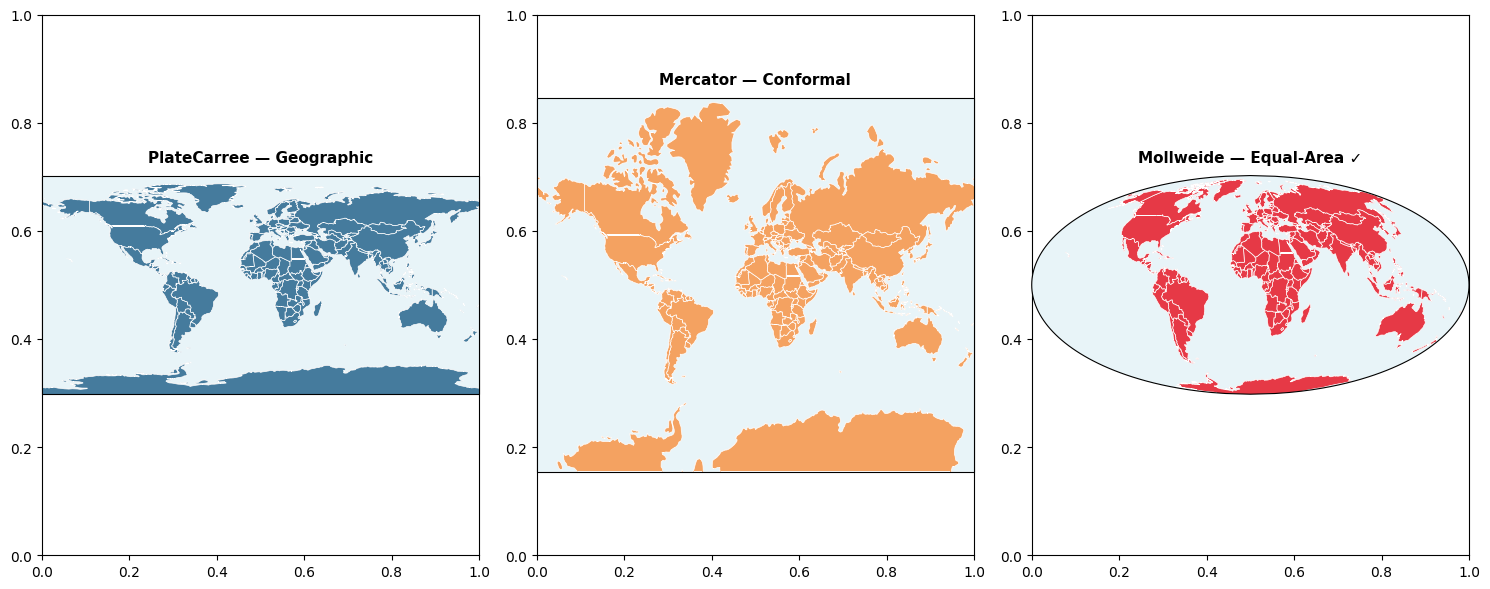

In [18]:

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

projections = [
    (ccrs.PlateCarree(),   'PlateCarree — Geographic',  '#457b9d'),
    (ccrs.Mercator(),      'Mercator — Conformal',       '#f4a261'),
    (ccrs.Mollweide(),     'Mollweide — Equal-Area ✓',   '#e63946'),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 6),
    subplot_kw={'projection': None}
)

for i, (proj, title, color) in enumerate(projections):
    ax = fig.add_subplot(1, 3, i + 1, projection=proj)
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#e8f4f8')
    ax.add_feature(cfeature.LAND,  facecolor='#f0f0f0')
    for geom in world.geometry:
        ax.add_geometries(
            [geom], ccrs.PlateCarree(),
            facecolor=color, edgecolor='white', linewidth=0.5
        )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

#plt.suptitle('Same data, three projections', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import plotly.graph_objects as go

# -----------------------
# Parameters
# -----------------------
R = 1.0  # radius of the sphere (Earth)

# Point on the sphere (spherical coordinates)
theta = np.pi / 4   # polar angle
phi = np.pi / 3     # azimuthal angle

x0 = R * np.sin(theta) * np.cos(phi)
y0 = R * np.sin(theta) * np.sin(phi)
z0 = R * np.cos(theta)

# -----------------------
# Sphere surface
# -----------------------
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 80)

x = R * np.outer(np.cos(u), np.sin(v))
y = R * np.outer(np.sin(u), np.sin(v))
z = R * np.outer(np.ones_like(u), np.cos(v))

sphere = go.Surface(
    x=x, y=y, z=z,
    opacity=0.4,
    colorscale="Blues",
    showscale=False
)

# -----------------------
# Vector (arrow-like line)
# -----------------------
vector = go.Scatter3d(
    x=[0, x0],
    y=[0, y0],
    z=[0, z0],
    mode="lines+markers",
    line=dict(color="red", width=6),
    marker=dict(size=4),
    name="vector r"
)

# Point on sphere
point = go.Scatter3d(
    x=[x0],
    y=[y0],
    z=[z0],
    mode="markers",
    marker=dict(size=6, color="red"),
)

# -----------------------
# Axes (explicit lines)
# -----------------------
L = 1.5 * R

axes = [
    go.Scatter3d(x=[-L, L], y=[0, 0], z=[0, 0],
                 mode="lines", line=dict(color="black", width=4)),
    go.Scatter3d(x=[0, 0], y=[-L, L], z=[0, 0],
                 mode="lines", line=dict(color="black", width=4)),
    go.Scatter3d(x=[0, 0], y=[0, 0], z=[-L, L],
                 mode="lines", line=dict(color="black", width=4)),
]

# -----------------------
# Layout
# -----------------------
layout = go.Layout(
    scene=dict(
        xaxis=dict(title="X", showbackground=True),
        yaxis=dict(title="Y", showbackground=True),
        zaxis=dict(title="Z", showbackground=True),
        aspectmode="cube"
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

# -----------------------
# Figure
# -----------------------
fig = go.Figure(data=[sphere, vector, point] + axes, layout=layout)
fig.show()

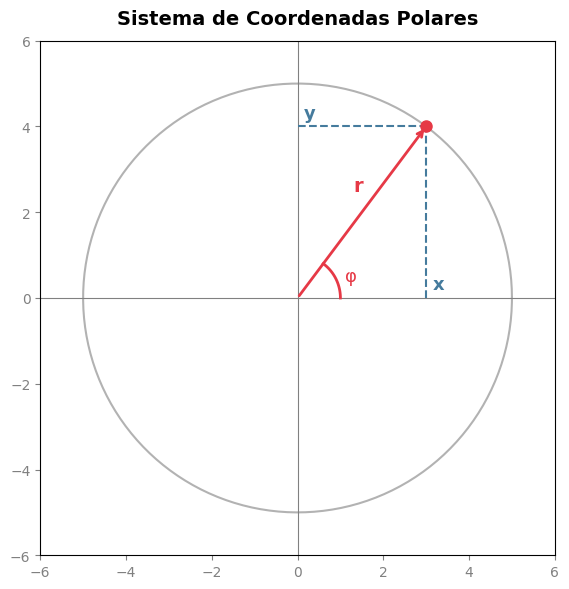

In [20]:

fig, ax = plt.subplots(figsize=(6, 6))

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(5 * np.cos(theta), 5 * np.sin(theta), color='grey', lw=1.5, alpha=0.6)

ax.axhline(0, color='grey', lw=0.8)
ax.axvline(0, color='grey', lw=0.8)

ax.annotate('', xy=(3, 4), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#e63946', lw=2))
ax.text(1.3, 2.5, 'r', color='#e63946', fontsize=14, fontweight='bold')

arc_theta = np.linspace(0, np.arctan2(4, 3), 50)
ax.plot(np.cos(arc_theta), np.sin(arc_theta), color='#e63946', lw=2)
ax.text(1.1, 0.4, 'φ', color='#e63946', fontsize=13)

ax.plot([3, 3], [0, 4], linestyle='--', color='#457b9d', lw=1.5)
ax.plot([0, 3], [4, 4], linestyle='--', color='#457b9d', lw=1.5)
ax.text(3.15, 0.2, 'x', color='#457b9d', fontsize=13, fontweight='bold')
ax.text(0.15, 4.2, 'y', color='#457b9d', fontsize=13, fontweight='bold')

ax.plot(3, 4, 'o', color='#e63946', markersize=8)

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.tick_params(colors='grey')
ax.set_title('Sistema de Coordenadas Polares', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [14]:
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [4]:
type(world)

geopandas.geodataframe.GeoDataFrame

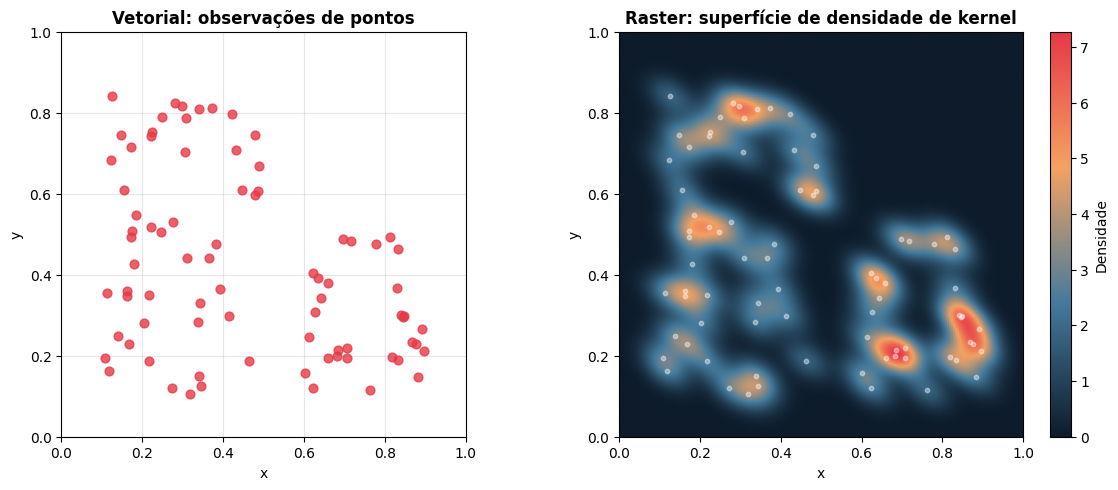

In [21]:
#| label: fig-vector-to-raster
#| fig-cap: "Esquerda: 80 observações de pontos brutos. Direita: a superfície de densidade de kernel derivada dos mesmos pontos — isso é um mapa de calor."

np.random.seed(42)
n = 80
x = np.concatenate([np.random.uniform(0.1, 0.5, 50),
                     np.random.uniform(0.6, 0.9, 30)])
y = np.concatenate([np.random.uniform(0.1, 0.9, 50),
                     np.random.uniform(0.1, 0.5, 30)])

xy = np.vstack([x, y])
kde = gaussian_kde(xy, bw_method=0.15)
grid_x, grid_y = np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200)
)
grid_z = kde(np.vstack([grid_x.ravel(), grid_y.ravel()])).reshape(200, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x, y, color='#e63946', s=40, alpha=0.8, zorder=3)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.set_aspect('equal')
ax1.set_title('Vetorial: observações de pontos', fontweight='bold', fontsize=12)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'heatmap', ['#0d1b2a', '#457b9d', '#f4a261', '#e63946']
)
im = ax2.imshow(
    grid_z, extent=[0, 1, 0, 1], origin='lower',
    cmap=cmap, aspect='equal'
)
ax2.scatter(x, y, color='white', s=10, alpha=0.4, zorder=3)
plt.colorbar(im, ax=ax2, label='Densidade')
ax2.set_title('Raster: superfície de densidade de kernel', fontweight='bold', fontsize=12)
ax2.set_xlabel('x'); ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

/tmp/ipykernel_776829/1943286594.py:22: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(x_grid, y_grid, density, levels=20, cmap='viridis', alpha=0.6, label='Density')


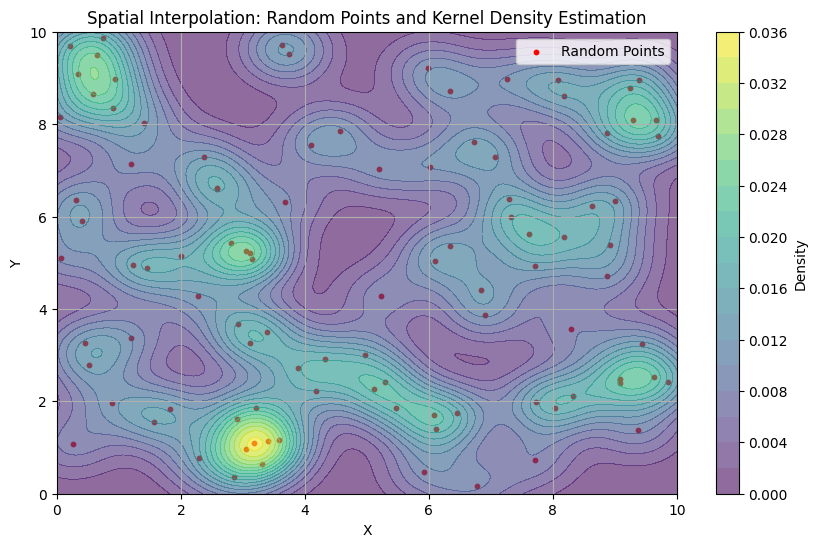

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Generate random 2D points
np.random.seed(42)
points = np.random.rand(100, 2) * 10  # 100 points in [0, 10] x [0, 10]

# Fit Kernel Density Estimation
kde = KernelDensity(bandwidth=0.5, metric='euclidean')
kde.fit(points)

# Create a grid for density evaluation
x_grid, y_grid = np.meshgrid(np.linspace(0, 10, 200), np.linspace(0, 10, 200))
grid_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T
log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(x_grid.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(points[:, 0], points[:, 1], s=10, c='red', label='Random Points')
plt.contourf(x_grid, y_grid, density, levels=20, cmap='viridis', alpha=0.6, label='Density')
plt.colorbar(label='Density')
plt.title('Interpolacao Espacial: Pontos Aleatórios e Densidade Kernel')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

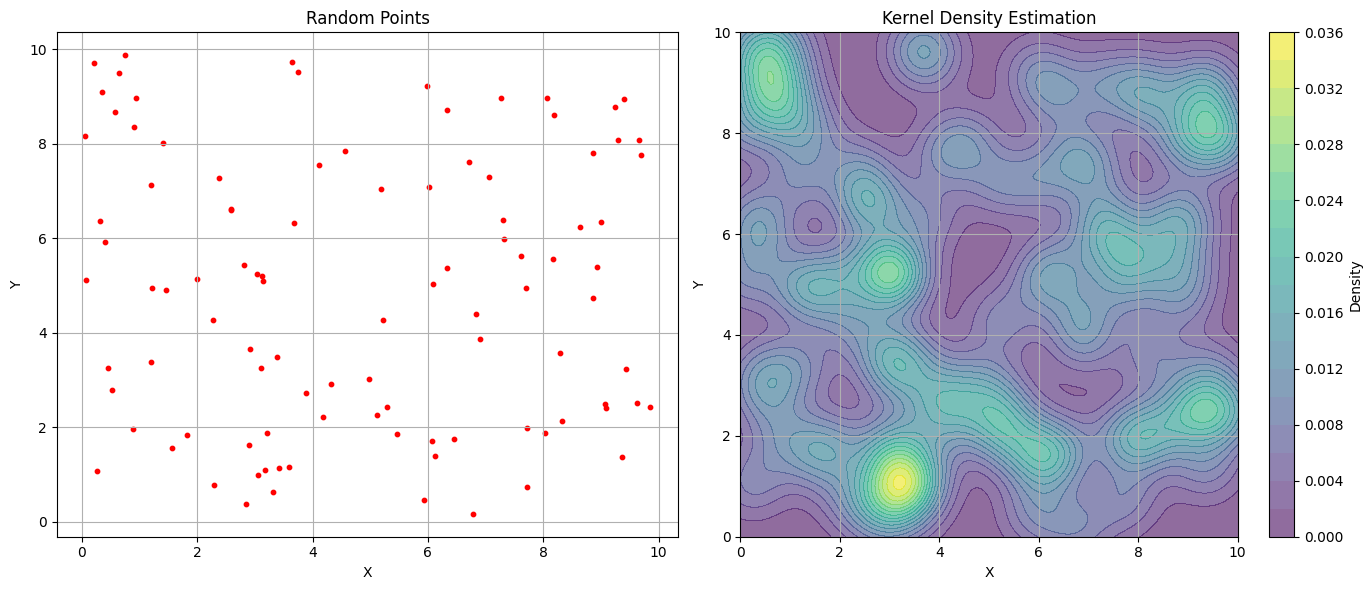

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Generate random 2D points
np.random.seed(42)
points = np.random.rand(100, 2) * 10  # 100 points in [0, 10] x [0, 10]

# Fit Kernel Density Estimation
kde = KernelDensity(bandwidth=0.5, metric='euclidean')
kde.fit(points)

# Create a grid for density evaluation
x_grid, y_grid = np.meshgrid(np.linspace(0, 10, 200), np.linspace(0, 10, 200))
grid_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T
log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(x_grid.shape)

# Create a 2-column subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# First subplot: Only the points
ax1.scatter(points[:, 0], points[:, 1], s=10, c='red')
ax1.set_title('Random Points')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.grid(True)

# Second subplot: Density estimation
contour = ax2.contourf(x_grid, y_grid, density, levels=20, cmap='viridis', alpha=0.6)
fig.colorbar(contour, ax=ax2, label='Density')
ax2.set_title('Kernel Density Estimation')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True)

plt.tight_layout()
plt.show()

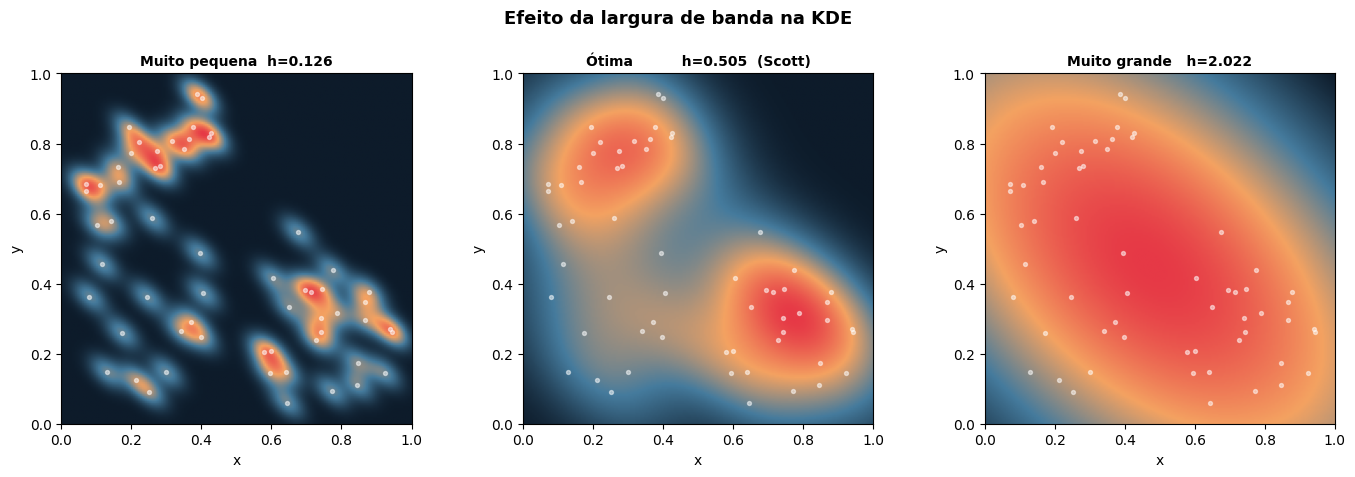

In [7]:
from scipy.stats import gaussian_kde
np.random.seed(13531)
n = 60
x2 = np.concatenate([np.random.uniform(0.05, 0.45, 35),
                      np.random.uniform(0.55, 0.95, 25)])
y2 = np.concatenate([np.random.uniform(0.05, 0.95, 35),
                      np.random.uniform(0.05, 0.55, 25)])
xy2 = np.vstack([x2, y2])

grid_x, grid_y = np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200)
)
grid_pts = np.vstack([grid_x.ravel(), grid_y.ravel()])

bw_scott = gaussian_kde(xy2).factor
bandwidths = [
    (bw_scott * 0.25, f'Muito pequena  h={bw_scott*0.25:.3f}'),
    (bw_scott,        f'Ótima          h={bw_scott:.3f}  (Scott)'),
    (bw_scott * 4,    f'Muito grande   h={bw_scott*4:.3f}'),
]

cmap = mcolors.LinearSegmentedColormap.from_list(
    'heatmap', ['#0d1b2a', '#457b9d', '#f4a261', '#e63946']
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (bw, title) in zip(axes, bandwidths):
    kde2 = gaussian_kde(xy2, bw_method=bw)
    z = kde2(grid_pts).reshape(200, 200)
    ax.imshow(z, extent=[0,1,0,1], origin='lower', cmap=cmap, aspect='equal')
    ax.scatter(x2, y2, color='white', s=8, alpha=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Efeito da largura de banda na KDE', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

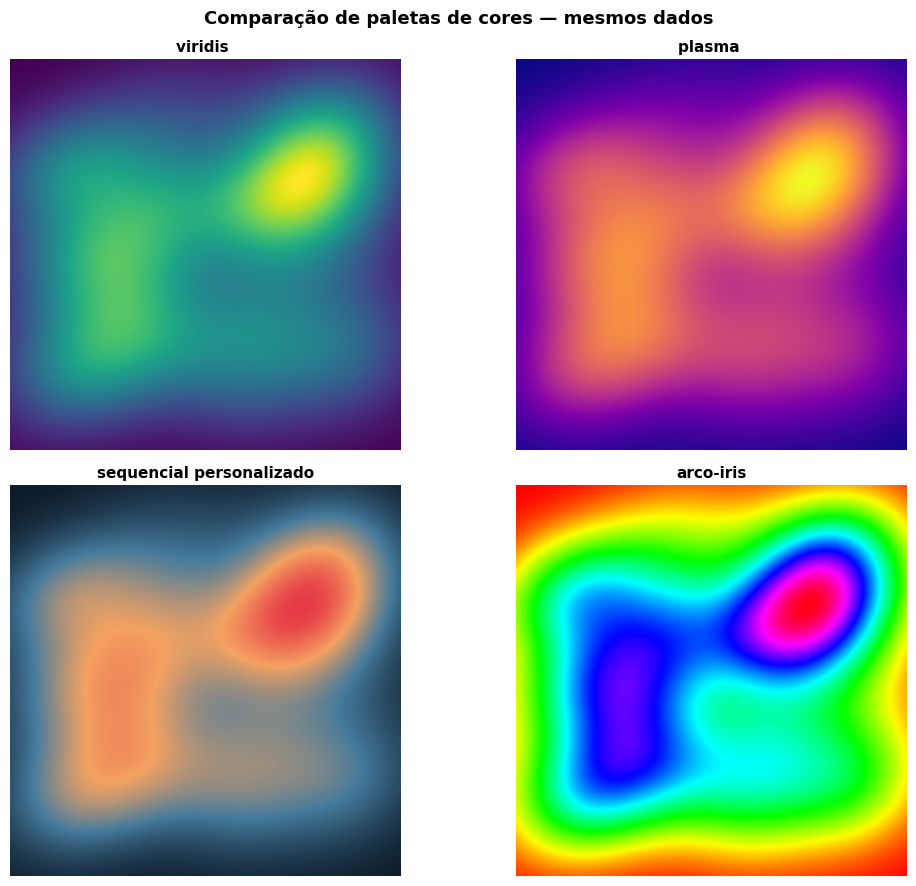

In [ ]:
np.random.seed(99)
x3 = np.concatenate([np.random.uniform(0.1, 0.45, 40),
                      np.random.uniform(0.55, 0.9, 40)])
y3 = np.random.uniform(0.1, 0.9, 80)
xy3 = np.vstack([x3, y3])
kde3 = gaussian_kde(xy3)
z3 = kde3(grid_pts).reshape(200, 200)

palettes = [
    ('viridis',  'viridis '),
    ('plasma',   'plasma '),
    (mcolors.LinearSegmentedColormap.from_list(
        'custom', ['#0d1b2a','#457b9d','#f4a261','#e63946']),
     'sequencial personalizado'),
    ('hsv',      'arco-iris'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (cmap_name, title) in zip(axes.flat, palettes):
    ax.imshow(z3, extent=[0,1,0,1], origin='lower',
              cmap=cmap_name, aspect='equal')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Comparação de paletas de cores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
world.ADMIN

0                             Fiji
1      United Republic of Tanzania
2                   Western Sahara
3                           Canada
4         United States of America
                  ...             
172             Republic of Serbia
173                     Montenegro
174                         Kosovo
175            Trinidad and Tobago
176                    South Sudan
Name: ADMIN, Length: 177, dtype: str

In [9]:
type(world.ADMIN)

pandas.Series

In [11]:
country_names = world.ADMIN
country_names.unique()

<StringArray>
[                       'Fiji', 'United Republic of Tanzania',
              'Western Sahara',                      'Canada',
    'United States of America',                  'Kazakhstan',
                  'Uzbekistan',            'Papua New Guinea',
                   'Indonesia',                   'Argentina',
 ...
                  'Somaliland',                      'Uganda',
                      'Rwanda',      'Bosnia and Herzegovina',
             'North Macedonia',          'Republic of Serbia',
                  'Montenegro',                      'Kosovo',
         'Trinidad and Tobago',                 'South Sudan']
Length: 177, dtype: str

In [12]:
country_names.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
172    False
173    False
174    False
175    False
176    False
Name: ADMIN, Length: 177, dtype: bool

In [13]:
sum(country_names.duplicated())

0